In [ ]:
# clustering and elbow

In [12]:
import pandas as pd
from sklearn.cluster import KMeans 
import matplotlib.pyplot as plt

#sample data
data = {
    'Costomer' : ['Riya', 'Aman', 'Sanu', 'Rashami', 'Lila', 'Rahul'],
    'Age' : [20, 30, 40, 22, 38, 25],
    'Spending' : [100, 200, 300, 110, 290, 130] 
}

df = pd.DataFrame(data) 

X = df[['Age', 'Spending']]
df

,Costomer,Age,Spending
0,Riya,20,100
1,Aman,30,200
2,Sanu,40,300
3,Rashami,22,110
4,Lila,38,290
5,Rahul,25,130


In [15]:

model = KMeans(n_clusters = 2, random_state = 42, n_init = 10)

df['group'] = model.fit_predict(X)
                         

C:\Users\jiyad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


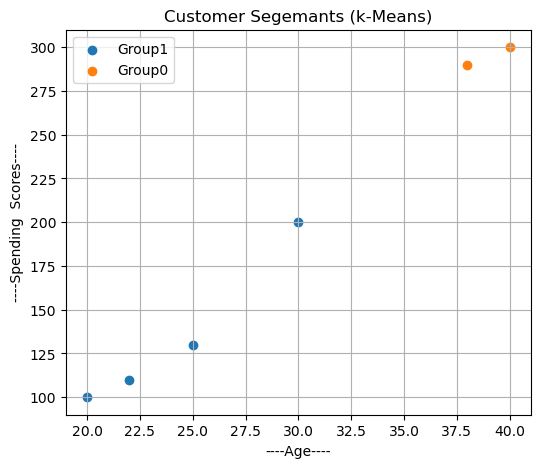

In [17]:

plt.figure(figsize = (6,5))
for group in df['group'].unique():  #(0,1)
    group_data = df[df['group'] == group]
    plt.scatter(group_data['Age'], group_data['Spending'], label = f"Group{group}")
plt.xlabel("----Age----")
plt.ylabel("----Spending  Scores----")
plt.title("Customer Segemants (k-Means)")
plt.legend()
plt.grid()
plt.show()       

In [ ]:
# standerScaler in K_means

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA

data = {
    "Age" : [25, 30, 35, 40, 45, 50],
    "Income" : [30000, 40000, 50000, 60000, 70000, 80000],
    "Spending" : [60, 50, 40, 30, 20, 10],
    "Savings" : [1000, 5000, 8000, 10000, 15000, 20000]
}
df = pd.DataFrame(data)
df


In [ ]:
# standardscaler convert all values into a real value that os called z - scores and formula of z-scores is z = (x-mean)/standard deviation
''' example   : 
"Income" : [30000, 40000, 50000, 60000, 70000, 80000]
mean = 30000 + 40000 + 50000 + 60000 + 70000 + 80000
mean = 55000
standard deviaiton = 18708.29(approx)
 z-score = (30000 - 55000)/18708.29
 z-score = -1.34

In [42]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

pca = PCA(n_components = 2)
pca_result = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_result, columns = ["PCA1", "PCA2"])
print(pca_df)

explained_variance= pca.explained_variance_ratio_
print("varience captured by each PCA Component")
print(np.round(explained_variance * 100, 2)) #comvert into persantage

       PCA1      PCA2
0 -2.901838  0.038962
1 -1.703939  0.088054
2 -0.585677 -0.001447
3  0.452949 -0.229542
4  1.730485 -0.041856
5  3.008020  0.145829
varience captured by each PCA Component
[99.65  0.35]


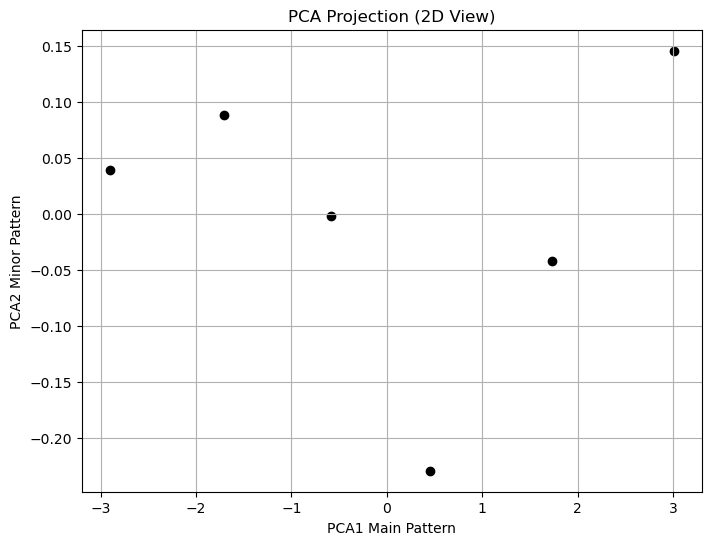

In [39]:
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PCA1'], pca_df["PCA2"], color="black")
plt.title("PCA Projection (2D View)")
plt.xlabel("PCA1 Main Pattern")
plt.ylabel("PCA2 Minor Pattern")
plt.grid(True)
plt.show()